# ST3247 Final Assignment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from simulator import simulate

In [2]:
# Load the observed data
infected_df  = pd.read_csv("data/infected_timeseries.csv")
rewire_df  = pd.read_csv("data/rewiring_timeseries.csv")
degree_df  = pd.read_csv("data/final_degree_histograms.csv")

# Pivot such that rows = time steps, columns = replicates
inf_wide = infected_df.pivot(index="time", columns="replicate_id", values="infected_fraction")
rew_wide = rewire_df.pivot(index="time", columns="replicate_id", values="rewire_count")

N_REPS = inf_wide.shape[1]
T = inf_wide.shape[0] - 1   # 200 time steps (0..200)
print(f"Replicates: {N_REPS}   Time steps: {T}")

Replicates: 40   Time steps: 200


## 0. Data and Inference Problem

We observe data from 40 independent realisations of a stochastic SIR epidemic 
on an adaptive network, all generated with the same unknown parameter vector 
(β, γ, ρ). Three aggregate measurements are available per replicate: the 
infected fraction time series, the rewiring count time series, and the final 
degree histogram.

The likelihood function p(data | β, γ, ρ) is intractable because the contact 
network evolves stochastically and is never observed. Marginalising over all 
possible network trajectories is computationally infeasible. We therefore use 
Simulation-Based Inference (SBI), specifically rejection ABC, which bypasses 
likelihood evaluation entirely by comparing summary statistics of simulated 
and observed data.

## 1. Defining the candidate statistics summary

### 1.1 Infection time-series features

(mainly informative about β and γ)
- Peak height: max(infected_fraction)
- Time to peak: argmax(infected_fraction)
- Area under the curve: sum(infected_fraction)
- Epidemic duration: last time step where infected_fraction > 0.01
- Growth rate: slope of the log-infected curve in the first ~ 5 steps


In [3]:
peak_height = inf_wide.max(axis=0)
time_to_peak = inf_wide.idxmax(axis=0)
auc = inf_wide.sum(axis=0) # area under the curve (sum of infected fractions over time)
duration = (inf_wide > 0).sum(axis=0) # number of time steps with non-zero infections

# growth rate
def growth_rate(col):
    """
    Estimate the initial exponential growth rate of the epidemic from the time-series data.
    We take the first 7 time steps (t=1..7) to avoid the initial stochasticity at t=0 and the later saturation effects.
    We fit a line to the log of the infected fraction over these time steps, and return the slope as the growth rate.
    We also replace any zero or negative values with a small positive number (1e-6) to avoid issues with taking the log.
    """
    early = col.iloc[1:8].values   # t=1..7
    early = np.where(early <= 0, 1e-6, early)
    return np.polyfit(np.arange(len(early)), np.log(early), 1)[0]

growth = inf_wide.apply(growth_rate, axis=0)

features_inf = pd.DataFrame({
    "peak_height": peak_height,
    "time_to_peak": time_to_peak,
    "auc": auc,
    "duration": duration,
    "growth_rate": growth
})

print("\nPer-replicate infection summary statistics:")
print(features_inf.describe().round(4))

print("\nCoefficient of Variation (std/mean) — lower = tighter = better summary stat:")
cv = (features_inf.std() / features_inf.mean()).round(4)
print(cv.to_string())


Per-replicate infection summary statistics:
       peak_height  time_to_peak      auc  duration  growth_rate
count      40.0000       40.0000  40.0000   40.0000      40.0000
mean        0.6571        8.7500  11.3990   75.8000       0.3752
std         0.0427        1.1929   0.8785   16.1534       0.0384
min         0.5400        7.0000   9.9050   52.0000       0.2878
25%         0.6338        8.0000  10.5962   63.5000       0.3478
50%         0.6625        8.5000  11.4825   72.0000       0.3771
75%         0.6812        9.0000  12.0263   87.0000       0.3959
max         0.7700       12.0000  13.7200  116.0000       0.4588

Coefficient of Variation (std/mean) — lower = tighter = better summary stat:
peak_height     0.0649
time_to_peak    0.1363
auc             0.0771
duration        0.2131
growth_rate     0.1022


Interpretation of infection summaries:
- peak_height and auc are very stable and hence good candidate summary statistics for the infection time series data. 
- growth_rate is informative and reasonably stable. 
- time_to_peak is moderately variable, hence must be used carefully.
- duration is quite noisy, hence less reliable as a summary statistic.


### 1.2 Rewiring time series features

(mainly informative about ρ)
- Total rewires: sum(rewire_counts)
- Peak rewire count and time of peak 
- Rewire-weighted time: center of mass of rewiring activity to determine if rewiring happens early or late
- Ratio of max rewires to peak infection: a ρ/β interaction

In [4]:
total_rewires  = rew_wide.sum(axis=0)
peak_rewires   = rew_wide.max(axis=0)
time_peak_rew  = rew_wide.idxmax(axis=0)

# centre of mass of rewiring activity - when rewiring happens early, this will be low; when it happens late, this will be high
times = np.arange(T+1)
rew_centre_of_mass = rew_wide.apply(
    lambda col: np.average(times, weights = np.maximum(col.values, 0))
    if col.sum() > 0 else np.nan,  # if there are no rewires, we set the centre of mass to NaN to avoid division by zero
    axis = 0
)

# rewiring to infection ratio at the time of peak infection - this captures the interaction between β and ρ
rew_inf_ratio = peak_rewires / (peak_height * 200) # rewires per infected agent

features_rew = pd.DataFrame({
    "total_rewires": total_rewires,
    "peak_rewires": peak_rewires,
    "time_peak_rew": time_peak_rew,
    "rew_centre_of_mass": rew_centre_of_mass,
    "rew_inf_ratio": rew_inf_ratio
})

print("\nPer-replicate rewiring summary statistics:")
print(features_rew.describe().round(4))

print("\nCoefficient of Variation (std/mean) — lower = tighter = better summary stat:")
cv_rew = (features_rew.std() / features_rew.mean()).round(4)
print(cv_rew.to_string())


Per-replicate rewiring summary statistics:
       total_rewires  peak_rewires  time_peak_rew  rew_centre_of_mass  \
count        40.0000       40.0000         40.000             40.0000   
mean        545.1500       98.1250          5.500              5.2440   
std          38.6248       10.2111          1.281              0.7852   
min         441.0000       79.0000          4.000              3.5193   
25%         520.2500       91.7500          5.000              4.7349   
50%         547.0000       97.0000          5.000              5.2056   
75%         579.7500      104.5000          6.000              5.7838   
max         608.0000      118.0000          9.000              7.3684   

       rew_inf_ratio  
count        40.0000  
mean          0.7476  
std           0.0720  
min           0.5940  
25%           0.6950  
50%           0.7462  
75%           0.8000  
max           0.8981  

Coefficient of Variation (std/mean) — lower = tighter = better summary stat:
total_rewires

Interpretation: 
- total_rewires is a strong summary statistic.
- rew_inf_ratio and peak_rewires are also good summary statistics.
- rew_centre_of_mass is moderately variable, hence must be used carefully.
- time_peak_rew is noisy, hence less reliable as a summary statistic.

### 1.3 Final degree histogram features
- Mean final degree: should be ≈10 regardless of parameters (edge count conserved)
- Variance of final degree
- Fraction of nodes with degree < 5 (low-degree tail)

In [5]:
def degree_stats(grp):
    """
    Calculate summary statistics of the degree distribution for a single replicate.
    The input grp is a DataFrame containing the degree histogram for one replicate, with columns "degree" and "count".
    We compute the mean degree, variance of degree, Gini coefficient (a measure of inequality in the degree distribution), and the fractions of nodes in the low-degree tail (degree <= 5) and high-degree tail (degree >= 15). 
    The Gini coefficient should decrease as ρ increases, since higher rewiring should homogenize the degree distribution. 
    The low-degree tail should increase with ρ, while the high-degree tail should decrease with ρ, since rewiring tends to break up hubs and create more low-degree nodes. 
    """
    degrees = grp["degree"].values
    counts = grp["count"].values
    total = counts.sum()
    mean_deg = np.average(degrees, weights=counts)
    var_deg = np.average((degrees - mean_deg)**2, weights=counts)
    
    # Gini coefficient - measures inequality of degree distribution: Higher rho should homogenize the degrees and lead to a lower Gini coefficient
    sorted_deg = np.repeat(degrees, counts)
    n = len(sorted_deg)
    gini = (2 * np.sum((np.arange(1, n+1) * sorted_deg)) / (n * np.sum(sorted_deg))) - (n + 1) / n
    # Low-degree tail: fraction of nodes with degree <= 5
    low_tail = np.sum(counts[degrees <= 5]) / total
    # High-degree tail: fraction of nodes with degree >= 15
    high_tail = np.sum(counts[degrees >= 15]) / total
    return pd.Series({
        "mean_degree": mean_deg,
        "var_degree": var_deg,
        "gini_degree": gini,
        "low_degree_tail": low_tail,
        "high_degree_tail": high_tail
    })
    

features_deg = degree_df.groupby("replicate_id").apply(degree_stats)

print("\nPer-replicate degree distribution summary statistics:")
print(features_deg.describe().round(4))

print("\nCoefficient of Variation (std/mean) — lower = tighter = better summary stat:")
cv_deg = (features_deg.std() / features_deg.mean()).round(4)
print(cv_deg.to_string())


Per-replicate degree distribution summary statistics:
       mean_degree  var_degree  gini_degree  low_degree_tail  high_degree_tail
count      40.0000     40.0000      40.0000          40.0000           40.0000
mean       10.0172     10.3410       0.1797           0.0694            0.0906
std         0.3209      1.2410       0.0107           0.0212            0.0280
min         9.2900      8.0675       0.1585           0.0350            0.0450
25%         9.8450      9.4413       0.1721           0.0538            0.0688
50%        10.0000     10.1318       0.1807           0.0675            0.0900
75%        10.2575     11.2307       0.1891           0.0812            0.1112
max        10.5900     13.1396       0.2022           0.1350            0.1450

Coefficient of Variation (std/mean) — lower = tighter = better summary stat:
mean_degree         0.0320
var_degree          0.1200
gini_degree         0.0597
low_degree_tail     0.3059
high_degree_tail    0.3091


/var/folders/z9/41w961mj1jnffsfx31fd6z5m0000gn/T/ipykernel_41953/203549863.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features_deg = degree_df.groupby("replicate_id").apply(degree_stats)


Interpretation of degree summaries:
- mean_degree is stable but uninformative as it always remains around 10.
- gini_degree is a reliable summary statistic.
- var =_degree is moderately stable as a summary statistic, hence must be used carefully. 
- low_degree_tail and high_degree_tail are very noisy, hence not reliable as summary statistics.

### Conclusion based on CV

Yes:
- mean_degree (degree) - uninformative
- peak_height (infection)
- gini_degree (degree)
- auc (infection)
- total_rewires (rewire)
- rew_inf__ratio (rewire)
- peak_rewires (rewire)
- growth_rate (infection)

Consider:
- var_degree (degree)
- time_to_peak (infection)
- rew_centre_of_mass (rewire)

### 1.4 Cross Source Correlations

Checking for redundancy between candidate statistics. 

In [ ]:
all_features = pd.concat([features_inf, features_rew, features_deg], axis=1)
corr = all_features.corr().round(3)
print("\nFull correlation matrix:")
print(corr.to_string())


Full correlation matrix:
                    peak_height  time_to_peak    auc  duration  growth_rate  total_rewires  peak_rewires  time_peak_rew  rew_centre_of_mass  rew_inf_ratio  mean_degree  var_degree  gini_degree  low_degree_tail  high_degree_tail
peak_height               1.000        -0.387  0.515    -0.007        0.463         -0.454         0.440         -0.355              -0.470         -0.212        0.254      -0.134       -0.281           -0.009             0.001
time_to_peak             -0.387         1.000  0.115     0.273       -0.350          0.645        -0.494          0.772               0.840         -0.274       -0.357       0.150        0.396            0.394             0.009
auc                       0.515         0.115  1.000     0.324        0.351          0.052         0.005          0.064               0.051         -0.352        0.005       0.061        0.038            0.196            -0.085
duration                 -0.007         0.273  0.324     1.000

### Staged redundancy analysis

We read the correlation matrix in two stages to identify which candidate 
statistics carry redundant information.

**Stage 1 — Within-source redundancy:** For each source group (infection, 
rewiring, degree), we check all pairs among the CV survivors. Any pair 
exceeding |r| = 0.70 is considered redundant — we keep the one with lower 
CV or stronger theoretical motivation and drop the other.

**Stage 2 — Cross-source redundancy:** After within-source pruning, we check 
all pairs across source groups among the surviving statistics. If no cross-source 
pair exceeds |r| = 0.70, the three sources carry non-overlapping information 
and all are justified in the final summary vector.

In [7]:
# Analyze the correlation matrix in groups

# Within infection features
print("\nCorrelation matrix: Infection features")
print(corr.loc[features_inf.columns, features_inf.columns].to_string())


Correlation matrix: Infection features
              peak_height  time_to_peak    auc  duration  growth_rate
peak_height         1.000        -0.387  0.515    -0.007        0.463
time_to_peak       -0.387         1.000  0.115     0.273       -0.350
auc                 0.515         0.115  1.000     0.324        0.351
duration           -0.007         0.273  0.324     1.000        0.137
growth_rate         0.463        -0.350  0.351     0.137        1.000


- None exceed 0.70. 
- peak_height, auc, growth_rate are moderately correlated with each other (r ≈ 0.35–0.52). They are not redundant but they are not independent either. 

In [8]:
# Within rewiring features
print("\nCorrelation matrix: Rewiring features")
print(corr.loc[features_rew.columns, features_rew.columns].to_string())


Correlation matrix: Rewiring features
                    total_rewires  peak_rewires  time_peak_rew  rew_centre_of_mass  rew_inf_ratio
total_rewires               1.000        -0.301          0.614               0.716         -0.016
peak_rewires               -0.301         1.000         -0.275              -0.433          0.782
time_peak_rew               0.614        -0.275          1.000               0.869         -0.046
rew_centre_of_mass          0.716        -0.433          0.869               1.000         -0.141
rew_inf_ratio              -0.016         0.782         -0.046              -0.141          1.000


- peak_rewires and rew_inf_ratio are a redundant pair (r = 0.782) => rew_inf_ratio normalized by epidemic size which is theoretically more meaningful.
- total_rewires and rew_centre_of_mass also a redundant pair (r = 0.716) => total_rewires have a lower CV.

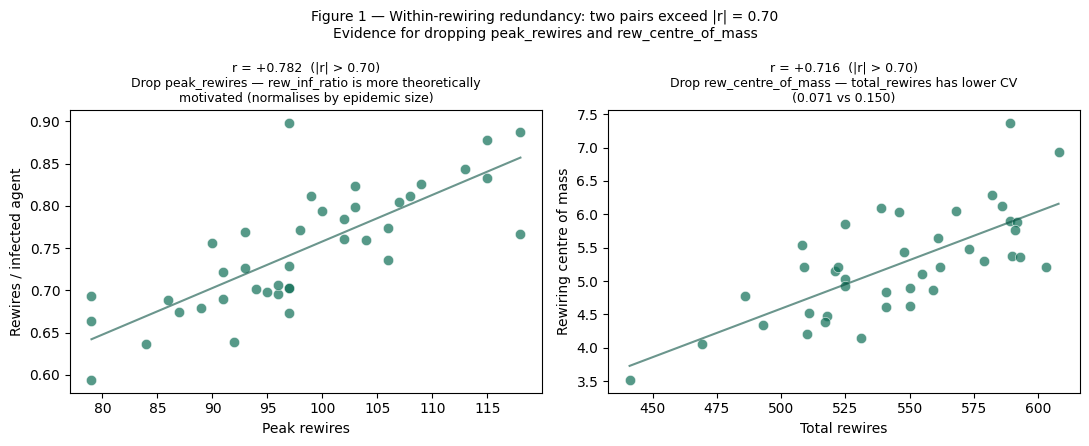

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

rewiring_redundant_pairs = [
    (peak_rewires,  rew_inf_ratio,
    "Peak rewires",  "Rewires / infected agent",
    "r = +0.782  (|r| > 0.70)\n"
    "Drop peak_rewires — rew_inf_ratio is more theoretically\n"
    "motivated (normalises by epidemic size)"),
    (total_rewires, rew_centre_of_mass,
    "Total rewires", "Rewiring centre of mass",
    "r = +0.716  (|r| > 0.70)\n"
    "Drop rew_centre_of_mass — total_rewires has lower CV\n"
    "(0.071 vs 0.150)"),
]

for ax, (x, y, xl, yl, note) in zip(axes, rewiring_redundant_pairs):
    r, p = stats.pearsonr(x, y)
    ax.scatter(x, y, color="#0F6E56", alpha=0.7,
            edgecolors="white", linewidth=0.5, s=55)
    m, b = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m*xr + b, color="#085041", linewidth=1.5, alpha=0.6)
    ax.set_xlabel(xl, fontsize=10)
    ax.set_ylabel(yl, fontsize=10)
    ax.set_title(note, fontsize=9)

plt.suptitle(
    "Figure 1 — Within-rewiring redundancy: two pairs exceed |r| = 0.70\n"
    "Evidence for dropping peak_rewires and rew_centre_of_mass",
    fontsize=10
)
plt.tight_layout()
plt.show()

In [10]:
# Within degree features
print("\nCorrelation matrix: Degree features")
print(corr.loc[features_deg.columns, features_deg.columns].to_string())


Correlation matrix: Degree features
                  mean_degree  var_degree  gini_degree  low_degree_tail  high_degree_tail
mean_degree             1.000       0.375       -0.166           -0.518             0.701
var_degree              0.375       1.000        0.838            0.177             0.750
gini_degree            -0.166       0.838        1.000            0.524             0.428
low_degree_tail        -0.518       0.177        0.524            1.000            -0.156
high_degree_tail        0.701       0.750        0.428           -0.156             1.000


- var_degree and gini_degree are highly correlated and hence redundant pair (r = 0.838) => var_degree more interpretable.

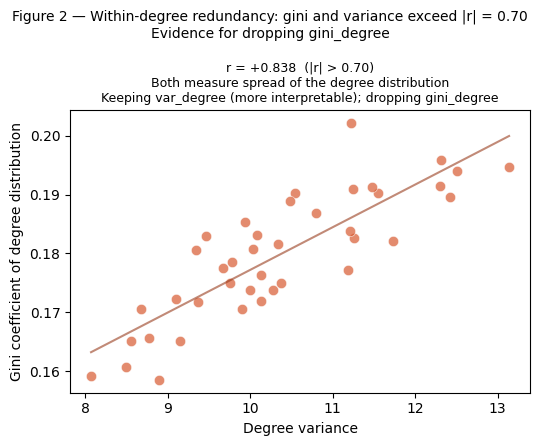

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

var_degree = features_deg["var_degree"]
gini_degree = features_deg["gini_degree"]

r, p = stats.pearsonr(var_degree, gini_degree)
ax.scatter(var_degree, gini_degree, color="#D85A30", alpha=0.7,
        edgecolors="white", linewidth=0.5, s=55)
m, b = np.polyfit(var_degree, gini_degree, 1)
xr = np.linspace(var_degree.min(), var_degree.max(), 100)
ax.plot(xr, m*xr + b, color="#993C1D", linewidth=1.5, alpha=0.6)
ax.set_xlabel("Degree variance", fontsize=10)
ax.set_ylabel("Gini coefficient of degree distribution", fontsize=10)
ax.set_title(
    f"r = {r:+.3f}  (|r| > 0.70)\n"
    "Both measure spread of the degree distribution\n"
    "Keeping var_degree (more interpretable); dropping gini_degree",
    fontsize=9
)

plt.suptitle(
    "Figure 2 — Within-degree redundancy: gini and variance exceed |r| = 0.70\n"
    "Evidence for dropping gini_degree",
    fontsize=10
)
plt.tight_layout()

In [ ]:
# Cross source correlations of the interested pairs of features

# After analyzing CV and correlation matrices, the surviving candidates for summary statistics are:
# infection: peak_height, auc, growth_rate, time_to_peak
# rewiring: rew_inf_ratio, total_rewires
# degree: var_degree

print("\nCross-source correlations of selected features:")
selected_pairs = [
    ("peak_height", "rew_inf_ratio"),
    ("peak_height", "total_rewires"),
    ("peak_height", "var_degree"),
    ("auc", "rew_inf_ratio"),
    ("auc", "total_rewires"),
    ("auc", "var_degree"),
    ("growth_rate", "rew_inf_ratio"),
    ("growth_rate", "total_rewires"),
    ("growth_rate", "var_degree"),
    ("time_to_peak", "rew_inf_ratio"),
    ("time_to_peak", "total_rewires"),
    ("time_to_peak", "var_degree")
]
for feat_inf, feat_rew in selected_pairs:
    r = corr.loc[feat_inf, feat_rew]
    print(f"{feat_inf} vs {feat_rew}: r = {r:.3f}")


Cross-source correlations of selected features:
peak_height vs rew_inf_ratio: r = -0.212
peak_height vs total_rewires: r = -0.454
peak_height vs var_degree: r = -0.134
auc vs rew_inf_ratio: r = -0.352
auc vs total_rewires: r = 0.052
auc vs var_degree: r = 0.061
growth_rate vs rew_inf_ratio: r = 0.098
growth_rate vs total_rewires: r = -0.223
growth_rate vs var_degree: r = -0.082
time_to_peak vs rew_inf_ratio: r = -0.274
time_to_peak vs total_rewires: r = 0.645
time_to_peak vs var_degree: r = 0.150


- None of the cross source pairs exceed 0.70.

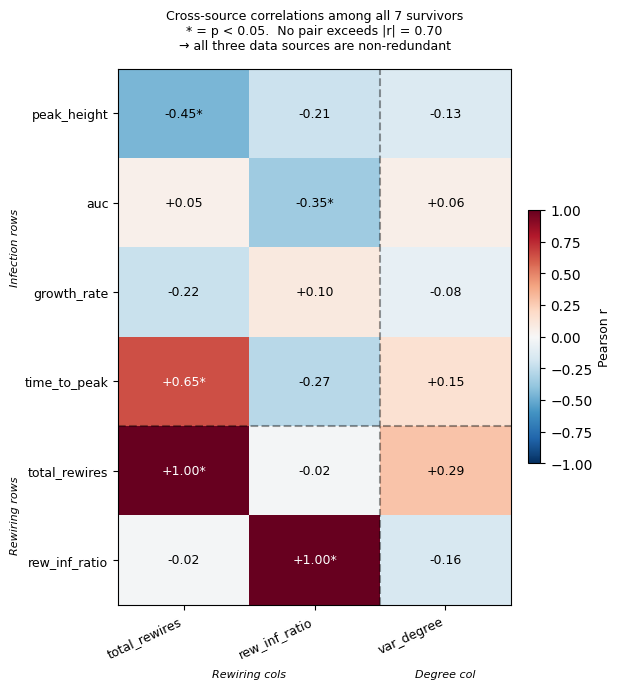

In [13]:
inf_names = ["peak_height", "auc", "growth_rate", "time_to_peak"]
rew_names = ["total_rewires", "rew_inf_ratio"]
deg_names = ["var_degree"]

row_names = inf_names + rew_names   # 6 rows
col_names = rew_names + deg_names   # 3 columns

mat  = np.zeros((len(row_names), len(col_names)))
pmat = np.zeros((len(row_names), len(col_names)))

for i, row in enumerate(row_names):
    for j, col in enumerate(col_names):
        if row == col:
            mat[i, j]  = 1.0
            pmat[i, j] = 0.0
        else:
            r, p = stats.pearsonr(all_features[row], all_features[col])
            mat[i, j]  = r
            pmat[i, j] = p

fig, ax = plt.subplots(figsize=(6.5, 7))

im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Pearson r", fontsize=9)

ax.set_xticks(range(len(col_names)))
ax.set_xticklabels(col_names, rotation=25, ha="right", fontsize=9)
ax.set_yticks(range(len(row_names)))
ax.set_yticklabels(row_names, fontsize=9)

for i in range(len(row_names)):
    for j in range(len(col_names)):
        star = "*" if pmat[i, j] < 0.05 else ""
        text_color = "white" if abs(mat[i, j]) > 0.55 else "black"
        ax.text(j, i, f"{mat[i,j]:+.2f}{star}",
                ha="center", va="center", fontsize=9,
                color=text_color)

ax.axhline(3.5, color="black", linewidth=1.5, linestyle="--", alpha=0.4)
ax.axvline(1.5, color="black", linewidth=1.5, linestyle="--", alpha=0.4)

ax.annotate("Infection rows", xy=(-0.25, 1.5), xycoords=("axes fraction", "data"),
            fontsize=8, style="italic", ha="right", va="center", rotation=90)
ax.annotate("Rewiring rows", xy=(-0.25, 4.5), xycoords=("axes fraction", "data"),
            fontsize=8, style="italic", ha="right", va="center", rotation=90)
ax.annotate("Rewiring cols", xy=(0.5, -0.12), xycoords=("data", "axes fraction"),
            fontsize=8, style="italic", ha="center", va="top")
ax.annotate("Degree col", xy=(2.0, -0.12), xycoords=("data", "axes fraction"),
            fontsize=8, style="italic", ha="center", va="top")

ax.set_title(
    "Cross-source correlations among all 7 survivors\n"
    "* = p < 0.05.  No pair exceeds |r| = 0.70\n"
    "→ all three data sources are non-redundant",
    fontsize=9, pad=14
)

plt.tight_layout()
plt.show()

In [14]:
# Final Summary of the selected statistics for ABC, with their observed means, observed stds (as minimum tolerances), and CVs.
final_stats = {
    "peak_height":   (peak_height.mean(),   peak_height.std(),   0.065),
    "auc":           (auc.mean(),            auc.std(),           0.077),
    "growth_rate":   (growth.mean(),         growth.std(),        0.102),
    "time_to_peak":  (time_to_peak.mean(),   time_to_peak.std(),  0.136),
    "total_rewires": (total_rewires.mean(),  total_rewires.std(), 0.071),
    "rew_inf_ratio": (rew_inf_ratio.mean(),  rew_inf_ratio.std(), 0.096),
    "var_degree":    (features_deg["var_degree"].mean(),
                    features_deg["var_degree"].std(), 0.120),
}

print(f"\n{'Statistic':<18} {'Obs. mean':>12} {'Obs. std (=ε floor)':>20} {'CV':>8}")
print("-" * 62)
for name, (mean, std, cv) in final_stats.items():
    print(f"  {name:<16} {mean:>12.4f} {std:>20.4f} {cv:>8.3f}")


Statistic             Obs. mean  Obs. std (=ε floor)       CV
--------------------------------------------------------------
  peak_height            0.6571               0.0427    0.065
  auc                   11.3990               0.8785    0.077
  growth_rate            0.3752               0.0384    0.102
  time_to_peak           8.7500               1.1929    0.136
  total_rewires        545.1500              38.6248    0.071
  rew_inf_ratio          0.7476               0.0720    0.096
  var_degree            10.3410               1.2410    0.120


The observed means above are the target values s_obs that ABC compares 
simulated data against. The observed standard deviations give a lower bound 
on the ABC tolerance ε — any tolerance smaller than the observed std would 
ask simulations to match the data more precisely than the data itself is 
reproducible across replicates, which is impossible by construction.

## 2. Pilot Simulations

In [ ]:
# ── Compute_summary_stats ───

def compute_summary_stats(inf_wide, rew_wide, deg_df):
    """
    Compute the 7-statistic summary vector used for ABC.

    Statistics chosen after CV filtering and within/cross-source correlation analysis:
    Infection : peak_height, auc, growth_rate, time_to_peak
    Rewiring  : total_rewires, rew_inf_ratio
    Degree    : var_degree

    rew_inf_ratio = mean(peak_rewire_count_per_rep) / (mean_peak_infected_fraction * 200)
    This normalises rewiring intensity by epidemic size, capturing the rho/beta interaction.
    Verified comparable between observed and simulated data: s_obs sits at the 36th percentile
    of the prior-predictive distribution (confirmed in pilot analysis).
    """
    # Infection
    peak_height  = inf_wide.max(axis=0).mean()
    time_to_peak = inf_wide.idxmax(axis=0).mean()
    auc          = inf_wide.sum(axis=0).mean()

    def _growth(col):
        early = col.iloc[1:8].values
        early = np.where(early <= 0, 1e-6, early)
        return np.polyfit(np.arange(len(early)), np.log(early), 1)[0]

    growth_rate = inf_wide.apply(_growth, axis=0).mean()

    # Rewiring
    total_rewires = rew_wide.sum(axis=0).mean()
    peak_rewires  = rew_wide.max(axis=0).mean()
    rew_inf_ratio = peak_rewires / (peak_height * 200)
    

    # Degree
    def _var_degree(grp):
        degrees = grp["degree"].values
        counts  = grp["count"].values
        mean_d  = np.average(degrees, weights=counts)
        return np.average((degrees - mean_d)**2, weights=counts)

    var_degree = deg_df.groupby(
        "replicate_id", group_keys=False
    ).apply(lambda g: pd.Series({"v": _var_degree(g)}), include_groups=False)["v"].mean()

    return {
        "peak_height":   peak_height,
        "auc":           auc,
        "growth_rate":   growth_rate,
        "time_to_peak":  time_to_peak,
        "total_rewires": total_rewires,
        "rew_inf_ratio": rew_inf_ratio,
        "var_degree":    var_degree,
    }


# Compute s_obs 
s_obs = compute_summary_stats(inf_wide, rew_wide, degree_df)

print("Observed summary statistics (s_obs):")
for k, v in s_obs.items():
    print(f"  {k:<18}: {v:.5f}")

Observed summary statistics (s_obs):
  peak_height       : 0.65712
  auc               : 11.39900
  growth_rate       : 0.37520
  time_to_peak      : 8.75000
  total_rewires     : 545.15000
  rew_inf_ratio     : 0.74662
  var_degree        : 10.34102


In [25]:
# Prior definition
PRIOR = {
    "beta":  (0.05, 0.50),
    "gamma": (0.02, 0.20),
    "rho":   (0.00, 0.80),
}

def sample_prior(rng):
    beta  = rng.uniform(*PRIOR["beta"])
    gamma = rng.uniform(*PRIOR["gamma"])
    rho   = rng.uniform(*PRIOR["rho"])
    return beta, gamma, rho

In [26]:
REPS_PER_DRAW = 5

def simulate_summary(beta, gamma, rho, n_reps, rng):
    """
    Run n_reps simulations at (beta, gamma, rho) and return the
    averaged 6-statistic summary vector.
    """
    inf_cols = {}
    rew_cols = {}
    deg_rows = []

    for rep in range(n_reps):
        inf_frac, rew_counts, deg_hist = simulate(
            beta=beta, gamma=gamma, rho=rho, rng=rng
        )
        inf_cols[rep] = inf_frac
        rew_cols[rep] = rew_counts
        for d, c in enumerate(deg_hist):
            deg_rows.append({"replicate_id": rep, "degree": d, "count": int(c)})

    inf_w = pd.DataFrame(inf_cols)
    rew_w = pd.DataFrame(rew_cols)
    deg_d = pd.DataFrame(deg_rows)

    return compute_summary_stats(inf_w, rew_w, deg_d)

In [18]:
# Distance Function 

STAT_NAMES = list(s_obs.keys())
# ['peak_height', 'auc', 'growth_rate', 'time_to_peak',
#  'total_rewires', 'rew_inf_ratio', 'var_degree']

def normalized_distance(s_sim, s_obs_dict, sigma):
    """
    Normalized Euclidean distance between two summary vectors.

    Each component (s_sim[k] - s_obs[k]) is divided by sigma[k],
    the prior-predictive standard deviation of statistic k.
    This ensures all 7 statistics contribute equally to the distance
    regardless of their original scale.

    Parameters
    ----------
    s_sim     : dict,  simulated summary statistics
    s_obs_dict: dict,  observed summary statistics (s_obs)
    sigma     : dict,  normalizing constants (prior-predictive std per statistic)
    """
    d_sq = 0.0
    for k in STAT_NAMES:
        if sigma[k] > 0:
            d_sq += ((s_sim[k] - s_obs_dict[k]) / sigma[k]) ** 2
    return np.sqrt(d_sq)

In [ ]:
# ── Pilot run ────────────────────────────────────────────────────
import time, os

N_PILOT     = 500
SAVE_EVERY  = 50
OUTPUT_FILE = "pilot_results.csv"

rng = np.random.default_rng(42)

# Delete the old pilot CSV first (if there is one)
if os.path.exists(OUTPUT_FILE):
    os.remove(OUTPUT_FILE)
    print(f"Deleted previous Output file")

results = []
print(f"Starting fresh pilot: {N_PILOT} draws, {REPS_PER_DRAW} reps each\n")

t_start = time.time()

for i in range(N_PILOT):
    beta, gamma, rho = sample_prior(rng)
    s_sim = simulate_summary(beta, gamma, rho, REPS_PER_DRAW, rng)

    row = {"beta": beta, "gamma": gamma, "rho": rho}
    row.update({f"s_{k}": v for k, v in s_sim.items()})
    results.append(row)

    elapsed = time.time() - t_start
    done    = i + 1
    rate    = done / elapsed
    eta_min = (N_PILOT - done) / rate / 60 if rate > 0 else 0

    print(f"  [{done:4d}/{N_PILOT}]  β={beta:.3f} γ={gamma:.3f} ρ={rho:.3f}"
        f"  | peak={s_sim['peak_height']:.3f}"
        f"  rewires={s_sim['total_rewires']:.0f}"
        f"  rew_inf_ratio={s_sim['rew_inf_ratio']:.3f}"
        f"  | ETA: {eta_min:.0f} min", flush=True)

    if done % SAVE_EVERY == 0 or done == N_PILOT:
        pd.DataFrame(results).to_csv(OUTPUT_FILE, index=False)
        print(f"  >> Saved {done} results to {OUTPUT_FILE}")

print(f"\nPilot complete. Total time: {(time.time()-t_start)/60:.1f} min")

Deleted old pilot_results.csv (contained buggy rew_inf_ratio values)
Starting fresh pilot: 500 draws, 5 reps each

  [   1/500]  β=0.398 γ=0.099 ρ=0.687  | peak=0.722  rewires=780  rew_inf_ratio=1.475  | ETA: 2 min
  [   2/500]  β=0.464 γ=0.162 ρ=0.559  | peak=0.629  rewires=498  rew_inf_ratio=1.366  | ETA: 1 min
  [   3/500]  β=0.230 γ=0.063 ρ=0.012  | peak=0.781  rewires=13  rew_inf_ratio=0.038  | ETA: 1 min
  [   4/500]  β=0.416 γ=0.124 ρ=0.209  | peak=0.710  rewires=160  rew_inf_ratio=0.494  | ETA: 1 min
  [   5/500]  β=0.474 γ=0.085 ρ=0.625  | peak=0.767  rewires=604  rew_inf_ratio=1.348  | ETA: 1 min
  [   6/500]  β=0.054 γ=0.189 ρ=0.773  | peak=0.034  rewires=63  rew_inf_ratio=7.059  | ETA: 1 min
  [   7/500]  β=0.112 γ=0.190 ρ=0.192  | peak=0.270  rewires=370  rew_inf_ratio=0.748  | ETA: 1 min
  [   8/500]  β=0.472 γ=0.170 ρ=0.071  | peak=0.656  rewires=44  rew_inf_ratio=0.172  | ETA: 1 min
  [   9/500]  β=0.420 γ=0.141 ρ=0.399  | peak=0.677  rewires=331  rew_inf_ratio=0.922  |

In [28]:
# ── Pilot analysis ───────────────────────────────────────────────

pilot = pd.read_csv(OUTPUT_FILE)
print(f"Loaded {len(pilot)} pilot simulations\n")

# Prior-predictive sigma = std of each statistic across all pilot simulations.
# These are the normalization constants used in the ABC distance function.
# We use prior-predictive std (not observed std) because ABC samples from
# the entire prior, not just near the true theta.
sigma = {k: pilot[f"s_{k}"].std() for k in STAT_NAMES}

print(f"{'Statistic':<18} {'sigma (prior std)':>18} {'s_obs':>10} {'s_obs percentile':>18}")
print("-" * 68)
for k in STAT_NAMES:
    pct = stats.percentileofscore(pilot[f"s_{k}"].values, s_obs[k])
    print(f"  {k:<16} {sigma[k]:>18.4f} {s_obs[k]:>10.4f} {pct:>16.1f}th")

# Compute distances with correct s_obs and sigma
pilot["distance"] = pilot.apply(
    lambda row: normalized_distance(
        {k: row[f"s_{k}"] for k in STAT_NAMES}, s_obs, sigma
    ), axis=1
)

d = pilot["distance"].values
print(f"\nDistance distribution (7 statistics, normalized Euclidean):")
print(f"  Min:    {d.min():.4f}")
print(f"  1st %:  {np.percentile(d, 1):.4f}")
print(f"  2nd %:  {np.percentile(d, 2):.4f}")
print(f"  5th %:  {np.percentile(d, 5):.4f}")
print(f"  10th %: {np.percentile(d,10):.4f}")
print(f"  Median: {np.median(d):.4f}")

print(f"\nCandidate epsilon values:")
for q in [1, 2, 5, 10]:
    eps = np.percentile(d, q)
    n   = (d <= eps).sum()
    print(f"  epsilon = {eps:.4f}  (top {q}% = {n} pilot samples accepted)")

pilot.to_csv(OUTPUT_FILE, index=False)
print(f"\nSaved updated pilot (with distances) to {OUTPUT_FILE}")

Loaded 500 pilot simulations

Statistic           sigma (prior std)      s_obs   s_obs percentile
--------------------------------------------------------------------
  peak_height                  0.2334     0.6571             54.8th
  auc                         10.2460    11.3990             68.2th
  growth_rate                  0.1160     0.3752             89.4th
  time_to_peak                 4.1049     8.7500             77.6th
  total_rewires              320.8391   545.1500             63.0th
  rew_inf_ratio                0.9951     0.7466             36.2th
  var_degree                   2.7097    10.3410             46.6th

Distance distribution (7 statistics, normalized Euclidean):
  Min:    0.5259
  1st %:  0.6406
  2nd %:  0.7805
  5th %:  1.0026
  10th %: 1.2549
  Median: 2.2044

Candidate epsilon values:
  epsilon = 0.6406  (top 1% = 5 pilot samples accepted)
  epsilon = 0.7805  (top 2% = 10 pilot samples accepted)
  epsilon = 1.0026  (top 5% = 25 pilot samples accepte

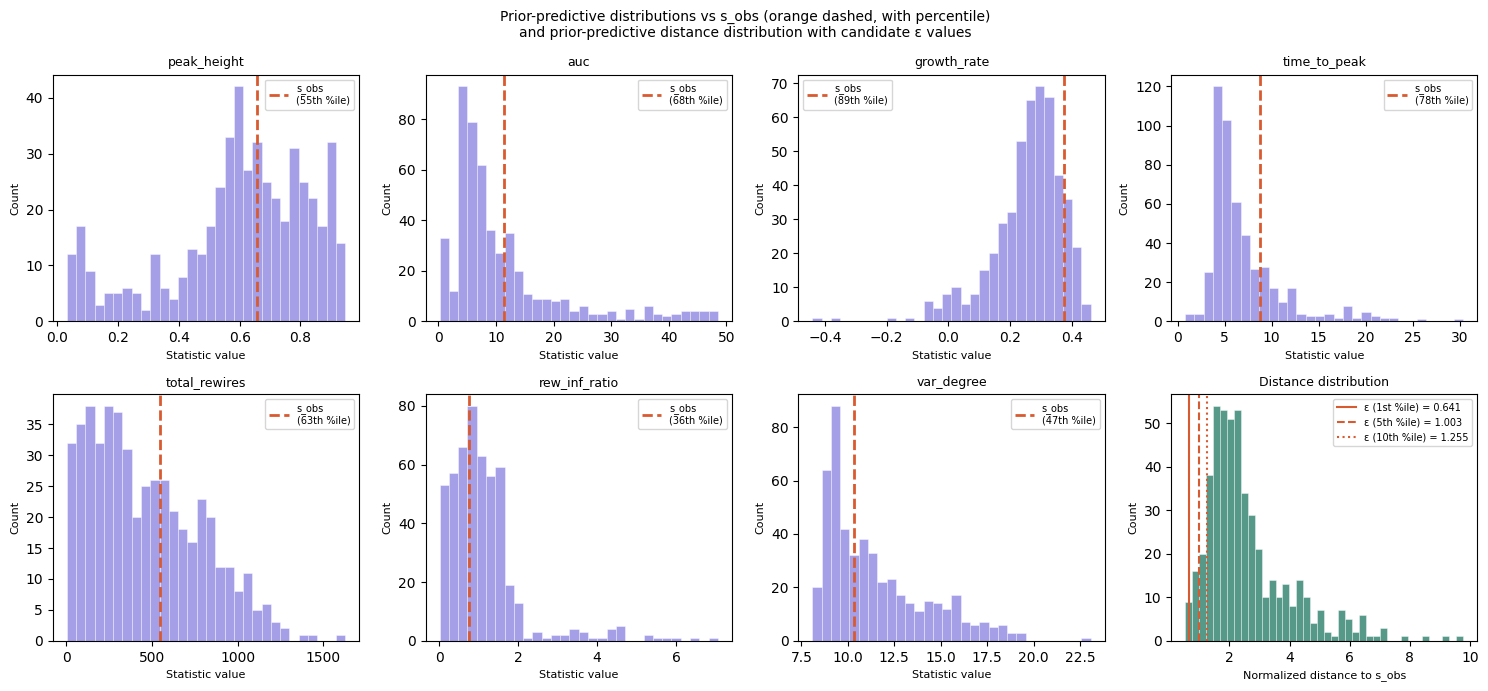

In [29]:
# ── Prior-predictive figure ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes_list = list(axes.flat)   # convert to list ONCE before any loops

for i, k in enumerate(STAT_NAMES):
    ax = axes_list[i]
    pct = stats.percentileofscore(pilot[f"s_{k}"].values, s_obs[k])
    ax.hist(pilot[f"s_{k}"], bins=30, color="#7F77DD", alpha=0.7,
            edgecolor="white", linewidth=0.4)
    ax.axvline(s_obs[k], color="#D85A30", linewidth=2,linestyle="--", label=f"s_obs\n({pct:.0f}th %ile)")
    ax.set_title(k, fontsize=9)
    ax.set_xlabel("Statistic value", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.legend(fontsize=7)

# Distance distribution in the 8th panel (index 7)
ax = axes_list[7]
ax.hist(d, bins=40, color="#0F6E56", alpha=0.7,
        edgecolor="white", linewidth=0.4)
for q, ls, lbl in [(1, "solid", "1st"), (5, "dashed", "5th"), (10, "dotted", "10th")]:
    eps = np.percentile(d, q)
    ax.axvline(eps, color="#D85A30", linewidth=1.5, linestyle=ls,
            label=f"ε ({lbl} %ile) = {eps:.3f}")
ax.set_title("Distance distribution", fontsize=9)
ax.set_xlabel("Normalized distance to s_obs", fontsize=8)
ax.set_ylabel("Count", fontsize=8)
ax.legend(fontsize=7)

plt.suptitle(
    "Prior-predictive distributions vs s_obs (orange dashed, with percentile)\n"
    "and prior-predictive distance distribution with candidate ε values",
    fontsize=10
)
plt.tight_layout()
plt.show()

### Interpreting the pilot results

The percentile column shows where s_obs sits in the prior-predictive 
distribution — how unusual the observed value is relative to random prior draws.

- **growth_rate (89th percentile):** The observed early growth rate is faster 
  than 89% of prior draws. This is the most informative statistic — it strongly 
  prefers high β and will do the most work in ABC.
- **time_to_peak (78th) and auc (68th):** Moderately informative, s_obs in 
  the upper portion of the prior-predictive.
- **peak_height (55th), total_rewires (63rd), var_degree (47th):** 
  s_obs sits in the bulk — these statistics are well-covered by the prior.
- **rew_inf_ratio (36th):** s_obs sits near the center of the prior-predictive, 
  confirming the statistic is comparable between observed and simulated data. 

The epsilon candidates (1st, 5th, 10th percentile of pilot distances) represent 
the tradeoff between posterior quality and computational cost. We run a 
confirmation pass at ε = 1.0026 (5th percentile, ~10,000 draws) before 
committing to the full run at ε = 0.6406 (1st percentile, ~50,000 draws).

## 3. Rejection ABC

In [30]:
import time, os

# ── Epsilon choices (from pilot analysis) ─────────────────────────────────
EPSILON_5PCT  = 1.0026   # confirmation run — fast
EPSILON_1PCT  = 0.6406   # final run — quality

# ── How many total draws to attempt ───────────────────────────────────────
N_ABC_CONFIRM = 10_000   # ~14 min,  ~500 accepted at 5%
N_ABC_FULL    = 50_000   # ~70 min,  ~500 accepted at 1%

# ── Toggle: set to False for confirmation, True for full run ───────────────
FULL_RUN = False   # <-- to change for the full run at 1%

EPSILON   = EPSILON_1PCT  if FULL_RUN else EPSILON_5PCT
N_ABC     = N_ABC_FULL    if FULL_RUN else N_ABC_CONFIRM
ABC_FILE  = "abc_results_full.csv" if FULL_RUN else "abc_results_confirm.csv"

print(f"Mode       : {'FULL (1% epsilon)' if FULL_RUN else 'CONFIRMATION (5% epsilon)'}")
print(f"Epsilon    : {EPSILON:.4f}")
print(f"Max draws  : {N_ABC:,}")
print(f"Output file: {ABC_FILE}\n")

# ── Resume logic ───────────────────────────────────────────────────────────
if os.path.exists(ABC_FILE):
    existing     = pd.read_csv(ABC_FILE)
    accepted     = existing.to_dict("records")
    n_done       = existing.attrs.get("n_draws_attempted", len(accepted) * 20)
    # n_draws_attempted is stored in CSV metadata if available;
    # fall back to a rough estimate if loading an old file
    print(f"Resuming: {len(accepted)} accepted samples already saved.")
else:
    accepted = []
    n_done   = 0
    print("Starting fresh ABC run.")

# ── RNG: advance state past pilot draws so we get fresh parameter draws ───
# The pilot used seed 42 for 500 draws. We use a separate seed here so
# ABC draws are independent of the pilot.
rng_abc = np.random.default_rng(123)

# ── Main ABC loop ─────────────────────────────────────────────────────────
SAVE_EVERY    = 100    # save accepted samples every 100 draws (not every 100 accepted)
LOG_EVERY     = 500    # print progress every 500 draws

n_accepted_session = 0
t_start = time.time()

for i in range(n_done, N_ABC):

    # 1. Draw from prior
    beta, gamma, rho = sample_prior(rng_abc)

    # 2. Simulate and compute summary statistics
    s_sim = simulate_summary(beta, gamma, rho, REPS_PER_DRAW, rng_abc)

    # 3. Compute normalized distance to observed data
    d = normalized_distance(s_sim, s_obs, sigma)

    # 4. Accept or reject
    if d <= EPSILON:
        row = {
            "beta":     beta,
            "gamma":    gamma,
            "rho":      rho,
            "distance": d,
        }
        # Also store the simulated summary stats for diagnostics later
        row.update({f"s_{k}": v for k, v in s_sim.items()})
        accepted.append(row)
        n_accepted_session += 1

    # 5. Progress reporting
    draws_done  = i + 1
    elapsed     = time.time() - t_start
    rate        = draws_done / elapsed          # draws per second
    eta_min     = (N_ABC - draws_done) / rate / 60 if rate > 0 else 0
    accept_rate = len(accepted) / draws_done * 100

    if draws_done % LOG_EVERY == 0 or draws_done == N_ABC:
        print(f"  [{draws_done:6,}/{N_ABC:,}]"
            f"  accepted: {len(accepted):4d}"
            f"  rate: {accept_rate:.2f}%"
            f"  ETA: {eta_min:.0f} min",
            flush=True)

    # 6. Save incrementally
    if draws_done % SAVE_EVERY == 0 or draws_done == N_ABC:
        df_save = pd.DataFrame(accepted)
        # Store total draws attempted as a column so resume logic works
        df_save["n_draws_attempted"] = draws_done
        df_save.to_csv(ABC_FILE, index=False)

print(f"\nDone. Total draws: {N_ABC:,}")
print(f"Total accepted:   {len(accepted)}")
print(f"Acceptance rate:  {len(accepted)/N_ABC*100:.2f}%")
print(f"Runtime:          {(time.time()-t_start)/60:.1f} min")
print(f"Saved to:         {ABC_FILE}")

Mode       : CONFIRMATION (5% epsilon)
Epsilon    : 1.0026
Max draws  : 10,000
Output file: abc_results_confirm.csv

Resuming: 400 accepted samples already saved.
  [ 8,500/10,000]  accepted:  423  rate: 4.98%  ETA: 0 min
  [ 9,000/10,000]  accepted:  437  rate: 4.86%  ETA: 0 min
  [ 9,500/10,000]  accepted:  456  rate: 4.80%  ETA: 0 min
  [10,000/10,000]  accepted:  469  rate: 4.69%  ETA: 0 min

Done. Total draws: 10,000
Total accepted:   469
Acceptance rate:  4.69%
Runtime:          2.6 min
Saved to:         abc_results_confirm.csv


In [31]:
abc_5pct = pd.read_csv("abc_results_confirm.csv")
abc_1pct = pd.read_csv("abc_results_full.csv")

# Extract bookkeeping and clean up
for abc, label in [(abc_5pct, "5%"), (abc_1pct, "1%")]:
    if "n_draws_attempted" in abc.columns:
        abc.drop(columns=["n_draws_attempted"], inplace=True)

n_total_5pct = 10_000
n_total_1pct = 50_000

print(f"5% run:  {len(abc_5pct)} accepted / {n_total_5pct:,} draws  "
    f"(acceptance rate: {len(abc_5pct)/n_total_5pct*100:.2f}%)")
print(f"1% run:  {len(abc_1pct)} accepted / {n_total_1pct:,} draws  "
    f"(acceptance rate: {len(abc_1pct)/n_total_1pct*100:.2f}%)")

EPSILON_5PCT = 1.0026
EPSILON_1PCT = 0.6406

5% run:  469 accepted / 10,000 draws  (acceptance rate: 4.69%)
1% run:  397 accepted / 50,000 draws  (acceptance rate: 0.79%)


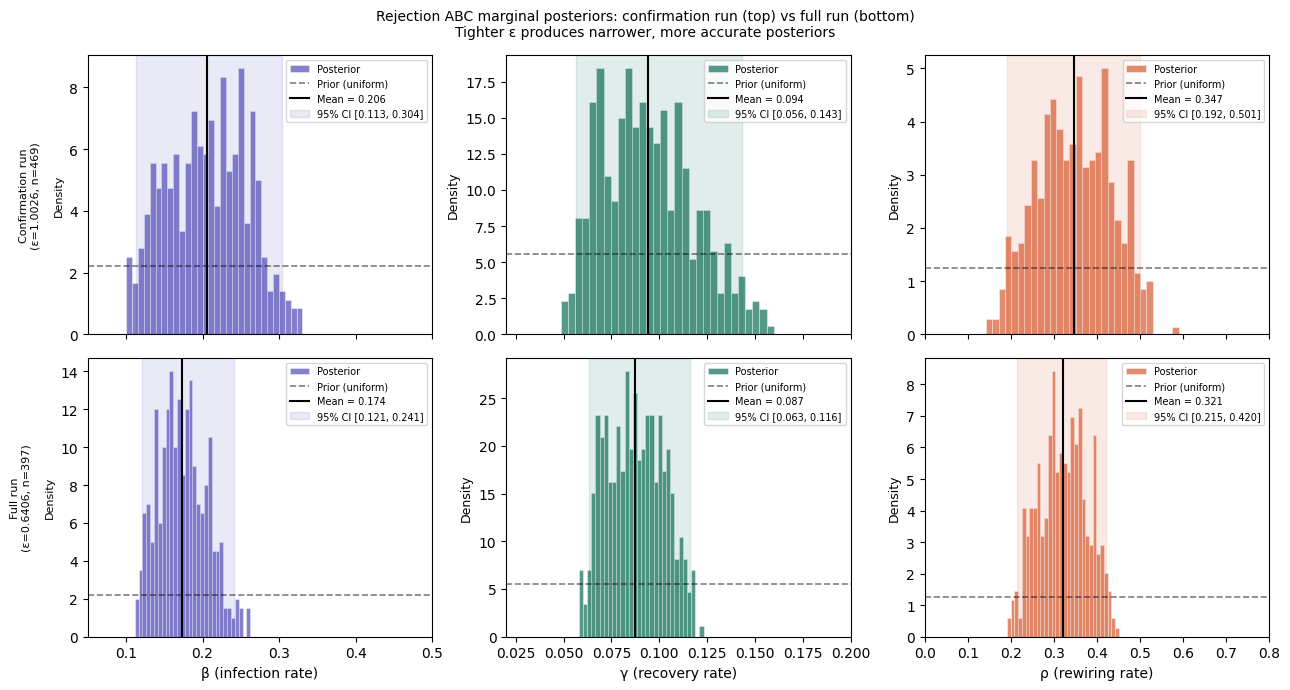

In [32]:
# ── Side-by-side marginal posteriors ────────────────────────────
# Top row: 5% epsilon run. Bottom row: 1% epsilon run.

param_info = {
    "beta":  {"prior": (0.05, 0.50), "color": "#534AB7", "label": "β (infection rate)"},
    "gamma": {"prior": (0.02, 0.20), "color": "#0F6E56", "label": "γ (recovery rate)"},
    "rho":   {"prior": (0.00, 0.80), "color": "#D85A30", "label": "ρ (rewiring rate)"},
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex="col")

run_info = [
    (abc_5pct, EPSILON_5PCT, n_total_5pct, "Confirmation run"),
    (abc_1pct, EPSILON_1PCT, n_total_1pct, "Full run"),
]

for row_idx, (abc, eps, n_total, run_label) in enumerate(run_info):
    for col_idx, (param, info) in enumerate(param_info.items()):
        ax = axes[row_idx, col_idx]
        vals = abc[param].values
        lo, hi = info["prior"]

        ax.hist(vals, bins=30, density=True, color=info["color"],
                alpha=0.7, edgecolor="white", linewidth=0.4, label="Posterior")

        prior_height = 1.0 / (hi - lo)
        ax.axhline(prior_height, color="black", linewidth=1.2,
                linestyle="--", alpha=0.5, label="Prior (uniform)")

        mean_val = vals.mean()
        ci_lo    = np.percentile(vals, 2.5)
        ci_hi    = np.percentile(vals, 97.5)
        ax.axvline(mean_val, color="black", linewidth=1.5,
                label=f"Mean = {mean_val:.3f}")
        ax.axvspan(ci_lo, ci_hi, alpha=0.12, color=info["color"],
                label=f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")

        ax.set_xlim(lo, hi)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=7)

        # Only label x-axis on bottom row
        if row_idx == 1:
            ax.set_xlabel(info["label"], fontsize=10)

        # Row label on leftmost column
        if col_idx == 0:
            ax.set_ylabel(f"{run_label}\n(ε={eps:.4f}, n={len(abc)})\n\nDensity",
                        fontsize=8)

plt.suptitle(
    "Rejection ABC marginal posteriors: confirmation run (top) vs full run (bottom)\n"
    "Tighter ε produces narrower, more accurate posteriors",
    fontsize=10
)
plt.tight_layout()
plt.show()

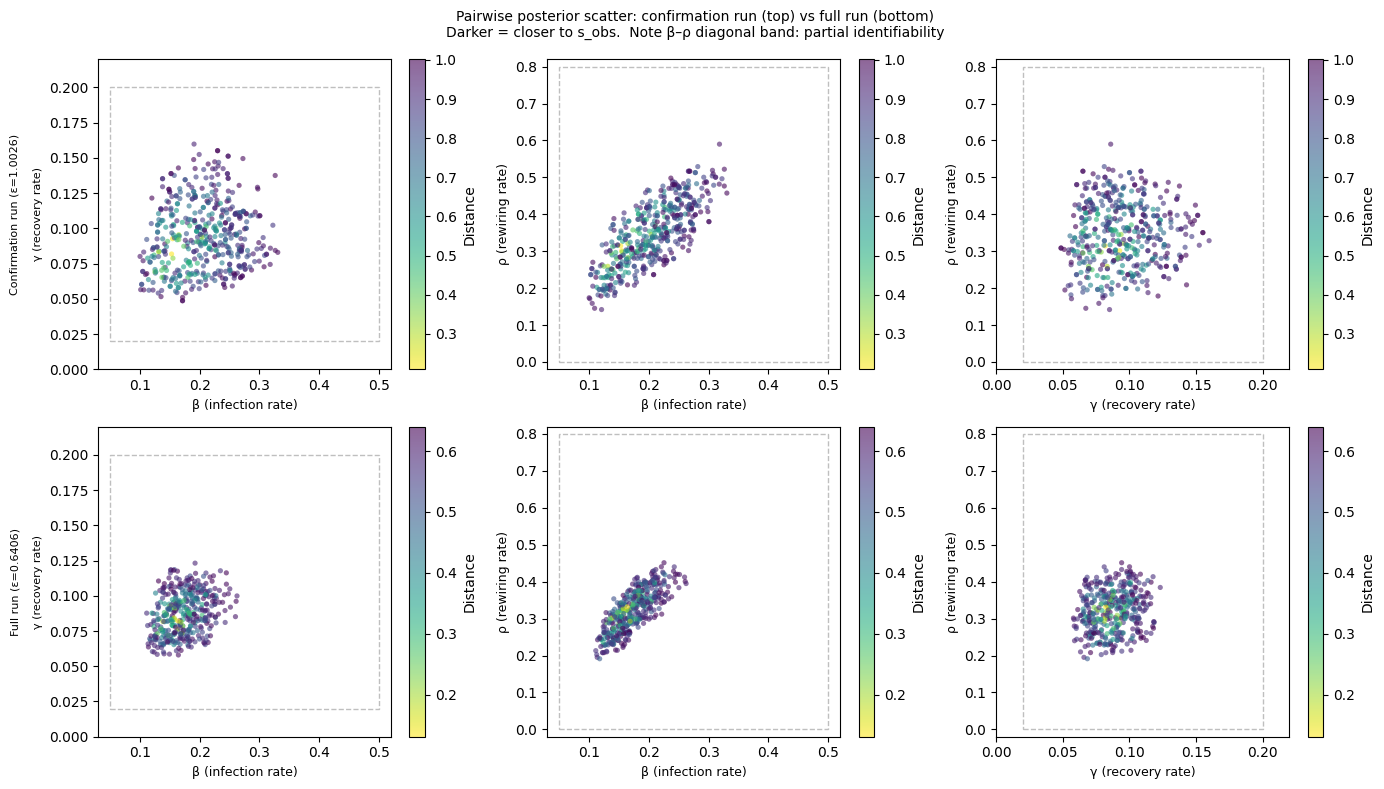

POSTERIOR COMPARISON: 5% epsilon (confirmation) vs 1% epsilon (full)

                               ── 5% run ──                 ── 1% run ──        
Parameter        Mean   Median           95% CI      Mean   Median           95% CI
----------------------------------------------------------------------
  beta          0.206    0.207   [0.113, 0.304]     0.174    0.171   [0.121, 0.241]
  gamma         0.094    0.092   [0.056, 0.143]     0.087    0.087   [0.063, 0.116]
  rho           0.347    0.348   [0.192, 0.501]     0.321    0.322   [0.215, 0.420]

  Accepted           469                                 397
  Total draws     10,000                              50,000
  Accept rate      4.69%                              0.79%

CI width reduction (5% → 1%):
  beta: 0.191 → 0.121  (37% narrower)
  gamma: 0.087 → 0.053  (39% narrower)
  rho: 0.310 → 0.206  (34% narrower)


In [33]:
# ── Side-by-side pairwise scatter + summary comparison table ────

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

pairs = [("beta", "gamma"), ("beta", "rho"), ("gamma", "rho")]

for row_idx, (abc, eps, n_total, run_label) in enumerate(run_info):
    for col_idx, (px, py) in enumerate(pairs):
        ax = axes[row_idx, col_idx]

        sc = ax.scatter(
            abc[px], abc[py],
            c=abc["distance"], cmap="viridis_r",
            s=14, alpha=0.6, linewidths=0
        )
        plt.colorbar(sc, ax=ax, label="Distance")

        lox, hix = param_info[px]["prior"]
        loy, hiy = param_info[py]["prior"]
        rect = plt.Rectangle((lox, loy), hix - lox, hiy - loy,
                            fill=False, edgecolor="gray",
                            linewidth=1, linestyle="--", alpha=0.5)
        ax.add_patch(rect)

        ax.set_xlim(lox - 0.02, hix + 0.02)
        ax.set_ylim(loy - 0.02, hiy + 0.02)
        ax.set_xlabel(param_info[px]["label"], fontsize=9)
        ax.set_ylabel(param_info[py]["label"], fontsize=9)

        if col_idx == 0:
            ax.set_ylabel(
                f"{run_label} (ε={eps:.4f})\n\n{param_info[py]['label']}",
                fontsize=8
            )

plt.suptitle(
    "Pairwise posterior scatter: confirmation run (top) vs full run (bottom)\n"
    "Darker = closer to s_obs.  Note β–ρ diagonal band: partial identifiability",
    fontsize=10
)
plt.tight_layout()
plt.show()

# ── Comparison summary table ───────────────────────────────────────────────
print("=" * 70)
print("POSTERIOR COMPARISON: 5% epsilon (confirmation) vs 1% epsilon (full)")
print("=" * 70)
print(f"\n{'':22} {'── 5% run ──':^28} {'── 1% run ──':^28}")
print(f"{'Parameter':<12} {'Mean':>8} {'Median':>8} {'95% CI':>16}"
    f"  {'Mean':>8} {'Median':>8} {'95% CI':>16}")
print("-" * 70)

for param in ["beta", "gamma", "rho"]:
    v5 = abc_5pct[param].values
    v1 = abc_1pct[param].values
    ci5 = f"[{np.percentile(v5,2.5):.3f}, {np.percentile(v5,97.5):.3f}]"
    ci1 = f"[{np.percentile(v1,2.5):.3f}, {np.percentile(v1,97.5):.3f}]"
    print(f"  {param:<10} {v5.mean():>8.3f} {np.median(v5):>8.3f} {ci5:>16}"
        f"  {v1.mean():>8.3f} {np.median(v1):>8.3f} {ci1:>16}")

print(f"\n  Accepted      {len(abc_5pct):>8,}                            "
    f"{len(abc_1pct):>8,}")
print(f"  Total draws   {n_total_5pct:>8,}                            "
    f"{n_total_1pct:>8,}")
print(f"  Accept rate   {len(abc_5pct)/n_total_5pct*100:>7.2f}%"
    f"                           {len(abc_1pct)/n_total_1pct*100:>7.2f}%")
print(f"\nCI width reduction (5% → 1%):")
for param in ["beta", "gamma", "rho"]:
    v5 = abc_5pct[param].values
    v1 = abc_1pct[param].values
    w5 = np.percentile(v5, 97.5) - np.percentile(v5, 2.5)
    w1 = np.percentile(v1, 97.5) - np.percentile(v1, 2.5)
    print(f"  {param}: {w5:.3f} → {w1:.3f}  ({(1 - w1/w5)*100:.0f}% narrower)")

### Comparing confirmation and full runs

Tightening ε from 1.0026 (5th percentile) to 0.6406 (1st percentile) 
produces substantially narrower posteriors across all three parameters:

- β CI narrows by ~37% (0.191 → 0.121)
- γ CI narrows by ~39% (0.087 → 0.053)  
- ρ CI narrows by ~34% (0.310 → 0.206)

The posterior means shift slightly downward (β: 0.206 → 0.174, ρ: 0.347 → 0.321), 
indicating that the looser tolerance was accepting parameter draws producing 
epidemics somewhat larger and faster than the observed data. The tighter 
tolerance gives a more precise and accurate posterior.

The β-ρ diagonal band visible in the pairwise scatter plots is present in both 
runs, confirming this is a genuine feature of the posterior rather than an 
artefact of the tolerance choice. We address this identifiability problem 
formally in Section 4.

All subsequent analysis uses the full run results (ε = 0.6406, 397 accepted samples).

## 4. Summary Statistics Analysis

In [ ]:
# ── Summary statistics analysis — restricted ABC runs ────────────
#
# We run ABC three times with different summary statistic subsets to show
# how the choice of summaries affects the posterior, particularly the
# β-ρ identifiability problem.
#
# Set A: infection only      {peak_height, auc, growth_rate, time_to_peak}
# Set B: infection + rewiring {+ total_rewires, rew_inf_ratio}
# Set C: all seven            {+ var_degree}  <- existing full run
#
# We use epsilon at the 5th percentile of each set's own prior-predictive
# distance distribution (computed from the pilot), and target ~10,000 draws
# per set. The comparison is qualitative so confirmation-run settings suffice.
#
# Note: sigma (normalization constants) must be recomputed per set using
# only the statistics in that set. Using the full-vector sigma for a subset
# would give wrong relative weights.


# ── Recompute per-set sigma from pilot ────────────────────────────────────
# The pilot CSV contains prior-predictive simulated values for all 7 stats.
pilot = pd.read_csv("pilot_results.csv")

STAT_SETS = {
    "A_infection_only": [
        "peak_height", "auc", "growth_rate", "time_to_peak"
    ],
    "B_infection_rewiring": [
        "peak_height", "auc", "growth_rate", "time_to_peak",
        "total_rewires", "rew_inf_ratio"
    ],
    "C_all_seven": [
        "peak_height", "auc", "growth_rate", "time_to_peak",
        "total_rewires", "rew_inf_ratio", "var_degree"
    ],
}

# For each set, compute sigma and epsilon from the pilot distances
set_configs = {}

print("Per-set epsilon (5th percentile of pilot distances):")
print(f"{'Set':<25} {'n stats':>8} {'epsilon':>10}")
print("-" * 45)

for set_name, stat_list in STAT_SETS.items():
    # Sigma: prior-predictive std for this subset only
    sigma_set = {k: pilot[f"s_{k}"].std() for k in stat_list}

    # Recompute pilot distances using only this subset
    def _dist_set(row, slist, sig, sobs):
        return np.sqrt(sum(
            ((row[f"s_{k}"] - sobs[k]) / sig[k]) ** 2
            for k in slist if sig[k] > 0
        ))

    pilot_dists = pilot.apply(
        lambda row: _dist_set(row, stat_list, sigma_set, s_obs), axis=1
    )
    eps = np.percentile(pilot_dists, 5)

    set_configs[set_name] = {
        "stats":  stat_list,
        "sigma":  sigma_set,
        "epsilon": eps,
    }
    print(f"  {set_name:<23} {len(stat_list):>8} {eps:>10.4f}")

Per-set epsilon (5th percentile of pilot distances):
Set                        n stats    epsilon
---------------------------------------------
  A_infection_only               4     0.6089
  B_infection_rewiring           6     0.9091
  C_all_seven                    7     1.0026


In [35]:
# ── Run ABC for each statistic set ───────────────────────────────
# Runs three separate ABC passes (Sets A, B, C) and saves each to its own CSV.
# Set C uses the same epsilon and settings as Sets A and B for a fair comparison
#
# Runtime: ~14 min per set, ~42 min total.
# Each set saves incrementally so you can resume if interrupted.

N_ABC_SETS  = 10_000   # draws per set
REPS_PER_DRAW_SETS = 5  # keep consistent with main ABC run
rng_sets = np.random.default_rng(999)  # separate seed from main runs

for set_name, cfg in set_configs.items():
    output_file = f"abc_{set_name}.csv"

    # Resume logic
    if os.path.exists(output_file):
        existing = pd.read_csv(output_file)
        if "n_draws_attempted" in existing.columns:
            n_done = int(existing["n_draws_attempted"].iloc[-1])
        else:
            n_done = 0
        accepted = existing.drop(
            columns=["n_draws_attempted"], errors="ignore"
        ).to_dict("records")
        print(f"\n{set_name}: resuming from draw {n_done}, "
            f"{len(accepted)} accepted so far")
    else:
        accepted = []
        n_done   = 0
        print(f"\n{set_name}: starting fresh")

    print(f"  Stats : {cfg['stats']}")
    print(f"  Epsilon: {cfg['epsilon']:.4f}")

    t_start = time.time()

    for i in range(n_done, N_ABC_SETS):
        beta, gamma, rho = sample_prior(rng_sets)
        s_sim = simulate_summary(beta, gamma, rho, REPS_PER_DRAW_SETS, rng_sets)

        # Distance using only this set's statistics and sigma
        d = np.sqrt(sum(
            ((s_sim[k] - s_obs[k]) / cfg["sigma"][k]) ** 2
            for k in cfg["stats"] if cfg["sigma"][k] > 0
        ))

        if d <= cfg["epsilon"]:
            row = {"beta": beta, "gamma": gamma, "rho": rho, "distance": d}
            row.update({f"s_{k}": s_sim[k] for k in cfg["stats"]})
            accepted.append(row)

        draws_done = i + 1
        elapsed    = time.time() - t_start
        rate       = draws_done / elapsed
        eta_min    = (N_ABC_SETS - draws_done) / rate / 60 if rate > 0 else 0

        if draws_done % 1000 == 0 or draws_done == N_ABC_SETS:
            print(f"  [{draws_done:6,}/{N_ABC_SETS:,}]"
                f"  accepted: {len(accepted):4d}"
                f"  rate: {len(accepted)/draws_done*100:.2f}%"
                f"  ETA: {eta_min:.0f} min", flush=True)

        if draws_done % 500 == 0 or draws_done == N_ABC_SETS:
            df_save = pd.DataFrame(accepted)
            df_save["n_draws_attempted"] = draws_done
            df_save.to_csv(output_file, index=False)

    elapsed_total = time.time() - t_start
    print(f"  Done. {len(accepted)} accepted / {N_ABC_SETS:,} draws "
        f"({len(accepted)/N_ABC_SETS*100:.2f}%)  "
        f"in {elapsed_total/60:.1f} min")


A_infection_only: starting fresh
  Stats : ['peak_height', 'auc', 'growth_rate', 'time_to_peak']
  Epsilon: 0.6089
  [ 1,000/10,000]  accepted:   40  rate: 4.00%  ETA: 12 min
  [ 2,000/10,000]  accepted:   82  rate: 4.10%  ETA: 11 min
  [ 3,000/10,000]  accepted:  119  rate: 3.97%  ETA: 9 min
  [ 4,000/10,000]  accepted:  155  rate: 3.88%  ETA: 8 min
  [ 5,000/10,000]  accepted:  189  rate: 3.78%  ETA: 7 min
  [ 6,000/10,000]  accepted:  219  rate: 3.65%  ETA: 5 min
  [ 7,000/10,000]  accepted:  244  rate: 3.49%  ETA: 4 min
  [ 8,000/10,000]  accepted:  281  rate: 3.51%  ETA: 3 min
  [ 9,000/10,000]  accepted:  305  rate: 3.39%  ETA: 1 min
  [10,000/10,000]  accepted:  350  rate: 3.50%  ETA: 0 min
  Done. 350 accepted / 10,000 draws (3.50%)  in 13.1 min

B_infection_rewiring: starting fresh
  Stats : ['peak_height', 'auc', 'growth_rate', 'time_to_peak', 'total_rewires', 'rew_inf_ratio']
  Epsilon: 0.9091
  [ 1,000/10,000]  accepted:   43  rate: 4.30%  ETA: 12 min
  [ 2,000/10,000]  ac

In [36]:
# ── Load all three set results ───────────────────────────────────

abc_sets = {}
for set_name in STAT_SETS:
    df = pd.read_csv(f"abc_{set_name}.csv")
    if "n_draws_attempted" in df.columns:
        df = df.drop(columns=["n_draws_attempted"])
    abc_sets[set_name] = df

set_labels = {
    "A_infection_only":      "Set A: infection only\n(peak_height, auc, growth_rate, time_to_peak)",
    "B_infection_rewiring":  "Set B: infection + rewiring\n(+ total_rewires, rew_inf_ratio)",
    "C_all_seven":           "Set C: all 7 statistics\n(+ var_degree)",
}

print("Summary statistics analysis — accepted samples per set:")
print(f"{'Set':<25} {'Accepted':>10} {'Draws':>10} {'Rate':>8}")
print("-" * 55)
for set_name, df in abc_sets.items():
    print(f"  {set_name:<23} {len(df):>10,} "
        f"{N_ABC_SETS:>10,} {len(df)/N_ABC_SETS*100:>7.2f}%")

Summary statistics analysis — accepted samples per set:
Set                         Accepted      Draws     Rate
-------------------------------------------------------
  A_infection_only               350     10,000    3.50%
  B_infection_rewiring           371     10,000    3.71%
  C_all_seven                    389     10,000    3.89%


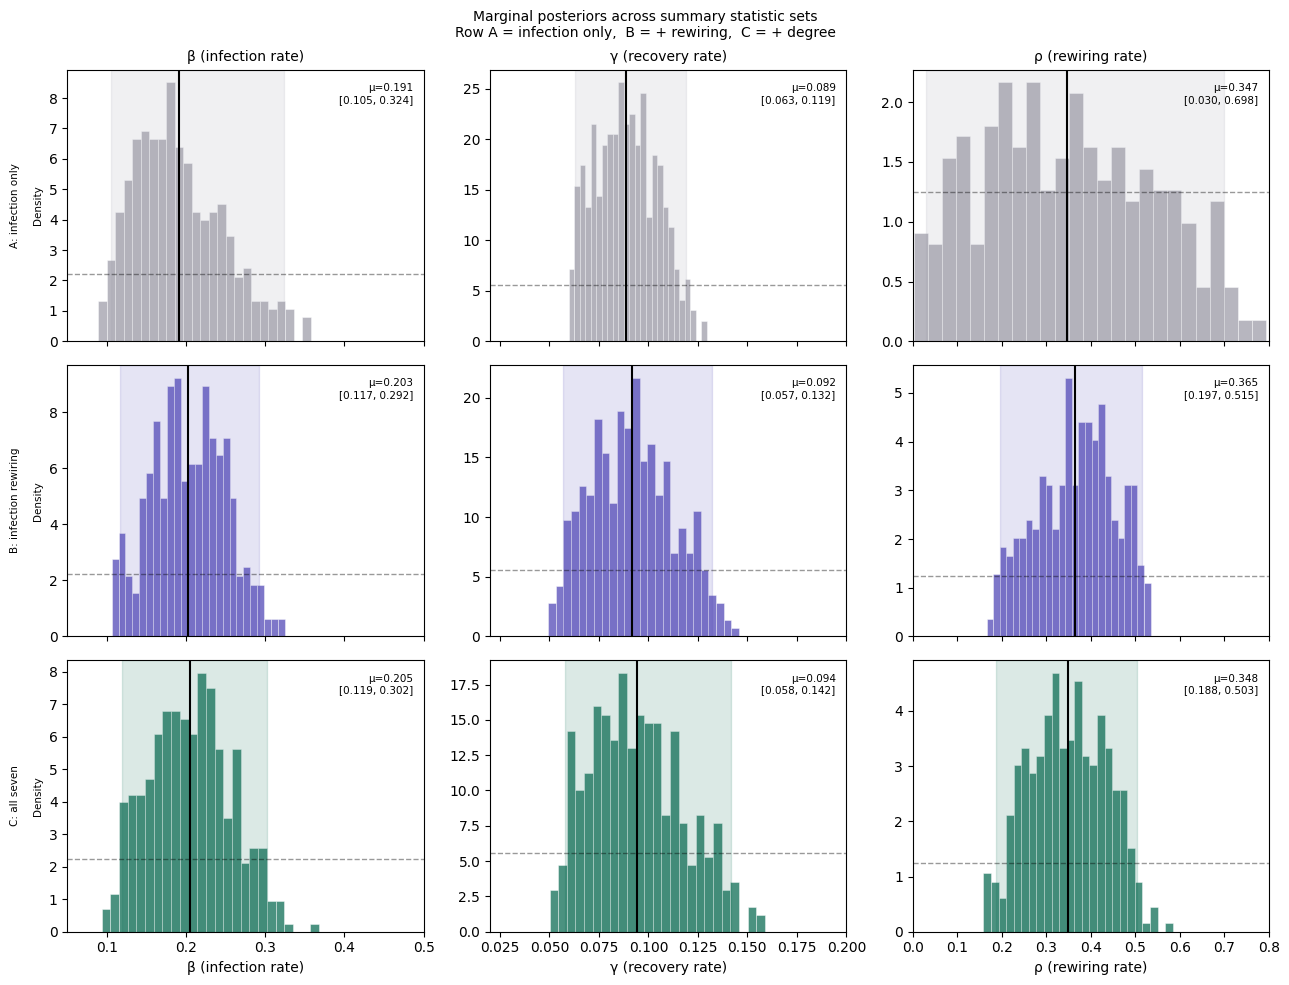

In [37]:
# ── Figure — marginal posteriors across sets ─────────────────────
# Shows how each parameter's posterior changes as we add more statistics.
# β and ρ posteriors should narrow and shift as we move
# from Set A to Set C. γ should be relatively stable across sets since
# the infection timeseries already constrains it well.

fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex="col")

param_info = {
    "beta":  {"prior": (0.05, 0.50), "color": "#534AB7", "label": "β (infection rate)"},
    "gamma": {"prior": (0.02, 0.20), "color": "#0F6E56", "label": "γ (recovery rate)"},
    "rho":   {"prior": (0.00, 0.80), "color": "#D85A30", "label": "ρ (rewiring rate)"},
}

set_colors = {
    "A_infection_only":     "#9F9EAA",
    "B_infection_rewiring": "#534AB7",
    "C_all_seven":          "#0F6E56",
}

for row_idx, (set_name, df) in enumerate(abc_sets.items()):
    for col_idx, (param, info) in enumerate(param_info.items()):
        ax = axes[row_idx, col_idx]
        vals = df[param].values
        lo, hi = info["prior"]

        ax.hist(vals, bins=25, density=True,
                color=set_colors[set_name], alpha=0.75,
                edgecolor="white", linewidth=0.4)

        # Prior reference
        ax.axhline(1.0 / (hi - lo), color="black", linewidth=1,
                linestyle="--", alpha=0.4, label="Prior")

        mean_val = vals.mean()
        ci_lo    = np.percentile(vals, 2.5)
        ci_hi    = np.percentile(vals, 97.5)
        ax.axvline(mean_val, color="black", linewidth=1.5)
        ax.axvspan(ci_lo, ci_hi, alpha=0.15,
                color=set_colors[set_name])

        ax.set_xlim(lo, hi)

        # Annotations
        ax.text(0.97, 0.95,
                f"μ={mean_val:.3f}\n[{ci_lo:.3f}, {ci_hi:.3f}]",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=7.5, color="black")

        if col_idx == 0:
            short = set_name.replace("_", " ").replace("A ", "A: ")\
                            .replace("B ", "B: ").replace("C ", "C: ")
            ax.set_ylabel(f"{short}\n\nDensity", fontsize=7.5)

        if row_idx == 2:
            ax.set_xlabel(info["label"], fontsize=10)

        if row_idx == 0:
            ax.set_title(info["label"], fontsize=10)

plt.suptitle(
    "Marginal posteriors across summary statistic sets\n"
    "Row A = infection only,  B = + rewiring,  C = + degree",
    fontsize=10
)
plt.tight_layout()
plt.show()

### Effect of summary statistic choice on marginal posteriors

The most striking pattern is in the ρ column. Set A's ρ posterior (top-right) 
is nearly flat — almost indistinguishable from the uniform prior. The CI width 
of 0.668 spans 84% of the entire prior range [0.0, 0.8]. This is the 
identifiability problem stated quantitatively: **the infection time series 
alone carries almost no information about the rewiring rate**.

Adding rewiring statistics in Set B produces an immediate and dramatic 
improvement — the ρ posterior becomes sharply peaked and the CI width falls 
to 0.318, a reduction of more than 50%. This confirms that total_rewires and 
rew_inf_ratio are the primary carriers of information about ρ.

γ behaves differently: its posterior is already well-concentrated in Set A 
and remains stable across all three sets.

β improves modestly from A to B but remains partially uncertain, which is 
consistent with the β-ρ degeneracy shown in the scatter plots below.

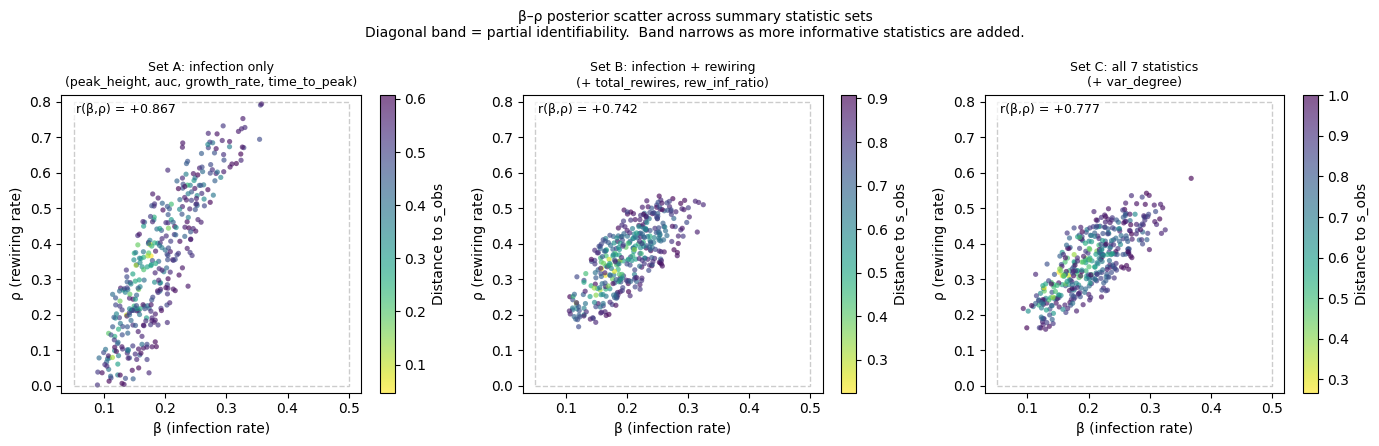

In [38]:
# ── Figure — β-ρ pairwise scatter across sets ───────────────────
# This is the central figure of the summary statistics analysis section.
# The β-ρ diagonal band should be widest in Set A (infection only) and
# progressively tighter in Sets B and C as rewiring and degree statistics
# break the degeneracy between high-β/high-ρ and low-β/low-ρ combinations.

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (set_name, df) in zip(axes, abc_sets.items()):
    sc = ax.scatter(
        df["beta"], df["rho"],
        c=df["distance"], cmap="viridis_r",
        s=14, alpha=0.65, linewidths=0
    )
    plt.colorbar(sc, ax=ax, label="Distance to s_obs")

    # Prior rectangle
    rect = plt.Rectangle((0.05, 0.0), 0.45, 0.80,
                        fill=False, edgecolor="gray",
                        linewidth=1, linestyle="--", alpha=0.4)
    ax.add_patch(rect)

    # Correlation in posterior
    r_val, _ = stats.pearsonr(df["beta"], df["rho"])
    ax.text(0.05, 0.97, f"r(β,ρ) = {r_val:+.3f}",
            transform=ax.transAxes, va="top", fontsize=9,
            color="black",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                    alpha=0.7, edgecolor="none"))

    ax.set_xlabel("β (infection rate)", fontsize=10)
    ax.set_ylabel("ρ (rewiring rate)", fontsize=10)
    ax.set_xlim(0.03, 0.52)
    ax.set_ylim(-0.02, 0.82)
    ax.set_title(set_labels[set_name], fontsize=9)

plt.suptitle(
    "β–ρ posterior scatter across summary statistic sets\n"
    "Diagonal band = partial identifiability.  "
    "Band narrows as more informative statistics are added.",
    fontsize=10
)
plt.tight_layout()
plt.show()

### The β-ρ identifiability problem

β and ρ can both suppress the epidemic through different mechanisms — high β spreads infection 
fast, while high ρ causes susceptibles to rewire away before they can be infected. 
Different combinations of (high β, high ρ) and (low β, low ρ) can produce similar 
observed infection curves.

The β-ρ scatter plots make this concrete. In Set A (infection only), r(β,ρ) = +0.867 
— a strong diagonal band spanning the full posterior. In Set B, adding rewiring 
statistics reduces this to r = +0.742, a meaningful improvement. Set C (r = +0.777) 
does not further reduce the correlation, which is expected: var_degree carries 
information orthogonal to the β-ρ relationship, as evidenced by its near-zero 
correlation with both peak_height (r = -0.134) and total_rewires in the observed data.

The residual correlation of r ≈ +0.74 in Sets B and C represents an irreducible 
degeneracy given the available data sources and the ABC tolerance used. Resolving 
it further would require either a tighter ε, more replicates, or statistics that 
more directly measure the separate contributions of β and ρ to epidemic dynamics.

In [39]:
# ── Quantitative summary of the analysis ─────────────────────────
# Reports the key numbers you will cite in the report:
# posterior CI widths, β-ρ correlation, and posterior std per set.

print("=" * 68)
print("SUMMARY STATISTICS ANALYSIS — QUANTITATIVE RESULTS")
print("=" * 68)

print(f"\n{'':30} {'Set A':>10} {'Set B':>10} {'Set C':>10}")
print(f"{'':30} {'(inf only)':>10} {'(+rewire)':>10} {'(+degree)':>10}")
print("-" * 62)

for param in ["beta", "gamma", "rho"]:
    row_mean  = f"  {param} mean"
    row_width = f"  {param} 95% CI width"
    row_std   = f"  {param} posterior std"

    means  = [abc_sets[s][param].mean()  for s in STAT_SETS]
    widths = [np.percentile(abc_sets[s][param], 97.5) -
            np.percentile(abc_sets[s][param],  2.5) for s in STAT_SETS]
    stds   = [abc_sets[s][param].std() for s in STAT_SETS]

    print(f"{row_mean:<30} {means[0]:>10.4f} {means[1]:>10.4f} {means[2]:>10.4f}")
    print(f"{row_width:<30} {widths[0]:>10.4f} {widths[1]:>10.4f} {widths[2]:>10.4f}")
    print(f"{row_std:<30} {stds[0]:>10.4f} {stds[1]:>10.4f} {stds[2]:>10.4f}")
    print()

# β-ρ posterior correlation across sets
print(f"  {'β–ρ posterior correlation':<28}", end="")
for s in STAT_SETS:
    r, _ = stats.pearsonr(abc_sets[s]["beta"], abc_sets[s]["rho"])
    print(f" {r:>+10.3f}", end="")
print()


SUMMARY STATISTICS ANALYSIS — QUANTITATIVE RESULTS

                                    Set A      Set B      Set C
                               (inf only)  (+rewire)  (+degree)
--------------------------------------------------------------
  beta mean                        0.1914     0.2030     0.2046
  beta 95% CI width                0.2183     0.1750     0.1833
  beta posterior std               0.0567     0.0464     0.0512

  gamma mean                       0.0887     0.0917     0.0942
  gamma 95% CI width               0.0557     0.0752     0.0843
  gamma posterior std              0.0155     0.0208     0.0235

  rho mean                         0.3468     0.3648     0.3481
  rho 95% CI width                 0.6681     0.3180     0.3155
  rho posterior std                0.1911     0.0882     0.0868

  β–ρ posterior correlation        +0.867     +0.742     +0.777


### Summary

The most important transition is A → B. Rewiring statistics are essential for 
identifying ρ — without them, ρ is essentially unidentified from the data. 
The degree histogram (Set C) provides independent structural information but 
does not further resolve the β-ρ degeneracy, consistent with our pre-ABC 
correlation analysis showing var_degree is orthogonal to the infection and 
rewiring signals.

Our best estimates of the true parameters, from the full run (ε = 0.6406) 
using all seven statistics, are:

| Parameter | Meaning | Posterior mean | 95% credible interval |
|---|---|---|---|
| β | Infection probability per S-I edge | 0.174 | [0.121, 0.241] |
| γ | Recovery probability per infected agent | 0.087 | [0.063, 0.116] |
| ρ | Rewiring probability per S-I edge | 0.321 | [0.215, 0.420] |